# Генерация случайного эллипса и зашумленных точек

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

In [50]:
def generate_noisy_ellipse(num_points=200, noise_level=0.2, noise_type='gaussian'):
    center = np.random.uniform(-100, 100, size=2)
    axis_a = np.random.uniform(3, 7)
    axis_b = np.random.uniform(1, 3)
    angle = np.random.uniform(0, 360)
    
    t = np.linspace(0, 2 * np.pi, num_points)
    x = axis_a * np.cos(t)
    y = axis_b * np.sin(t)

    angle_rad = np.deg2rad(angle)
    R = np.array([
        [np.cos(angle_rad), -np.sin(angle_rad)],
        [np.sin(angle_rad),  np.cos(angle_rad)]])
    
    ellipse_points = np.dot(np.stack((x, y), axis=1), R.T) + center
    
    if noise_type == 'gaussian':
        noise = np.random.normal(0, noise_level, ellipse_points.shape)
    elif noise_type == 'uniform':
        noise = np.random.uniform(-noise_level, noise_level, ellipse_points.shape)
        
    noisy_points = ellipse_points + noise
    
    return noisy_points, {
        'center': center,
        'axis_a': axis_a,
        'axis_b': axis_b,
        'angle' : angle }


In [51]:
num_points  = 100
noise_level = 0.4
noisy_points, ellipse_params = generate_noisy_ellipse(num_points=num_points, noise_level=noise_level)

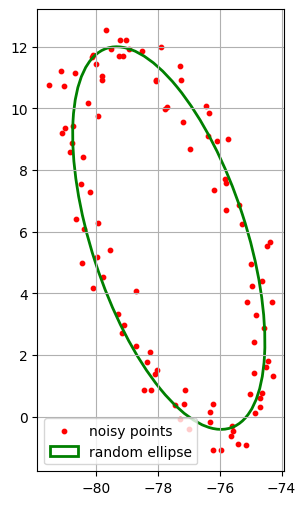

In [52]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(noisy_points[:, 0], noisy_points[:, 1], color='red', label='noisy points', s=10)

ellipse = Ellipse(
    xy          = ellipse_params['center'],
    width       = 2 * ellipse_params['axis_a'],
    height      = 2 * ellipse_params['axis_b'],
    angle       = ellipse_params['angle'],
    edgecolor   = 'green',
    facecolor   = 'none',
    linewidth   = 2,
    label       = 'random ellipse'
)
ax.add_patch(ellipse)

ax.set_aspect('equal')
ax.grid(True)
ax.legend()
plt.show()

In [53]:
def points_to_matrix(points):
    x = points[:, 0]
    y = points[:, 1]
    matrix = np.column_stack([x**2, x*y, y**2, x, y, np.ones(5)])
    return matrix

def fit_ellipse(points):
    M = points_to_matrix(points)
    _, _, V = np.linalg.svd(M)
    
    p = V[-1, :]  
    return p

def get_ellipse_parameters(P):
    A, B, C, D, E, F = P
    diskr = B**2 - 4*A*C
    if diskr >= 0:
        raise ValueError("Not ellipse")
    
    # max_coef = max(np.abs(P))
    A, B, C, D, E, F = P

    # Центр эллипса
    x0 = (2*C*D - B*E) / diskr
    y0 = (2*A*E - B*D) / diskr

    # Угол поворота
    if B == 0 and A < C:
        theta = 0
    elif B == 0 and A >= C:
        theta = np.pi / 2
    else:
        theta = 0.5 * np.arctan2(-B, C - A)
        
    # theta = theta % np.pi

    # Полуоси
    
    common = A*E**2 + C*D**2 - B*D*E + (B**2 - 4*A*C)*F
    term = np.sqrt((A - C)**2 + B**2)

    axis_major = -np.sqrt( 2 * common * (A + C + term) ) / (diskr)
    axis_minor = -np.sqrt( 2 * common * (A + C - term) ) / (diskr)


    # Гарантируем, что axis_a > axis_b
    if axis_minor > axis_major:
        axis_major, axis_minor = axis_minor, axis_major
        theta += (np.pi / 2)

    return x0, y0, axis_major, axis_minor, theta



def get_coefficients(x0, y0, a, b, angle):
        cos_theta = np.cos(angle)
        sin_theta = np.sin(angle)
        
        A = (sin_theta**2 * a**2) + (cos_theta**2 * b**2)
        B = 2 * cos_theta * sin_theta * (b**2 - a**2)
        C = (cos_theta**2 * a**2) + (sin_theta**2 * b**2)
        D = -2 * A * x0 - B * y0
        E = -B * x0 - 2 * C * y0
        F = A * x0**2 + B * x0 * y0 + C * y0**2 - a**2 * b**2
        return np.array([A, B, C, D, E, F])
    
def count_points(points, P_outer, P_inner):
    A_outer, B_outer, C_outer, D_outer, E_outer, F_outer = P_outer
    A_inner, B_inner, C_inner, D_inner, E_inner, F_inner = P_inner
    
    x = points[:, 0]
    y = points[:, 1]
    
    outer_values = (A_outer * x**2 + B_outer * x * y + C_outer * y**2 +
                    D_outer * x + E_outer * y + F_outer)
    
    inner_values = (A_inner * x**2 + B_inner * x * y + C_inner * y**2 +
                    D_inner * x + E_inner * y + F_inner)
    
    is_inside_outer = outer_values < 0
    is_outside_inner = inner_values > 0
    is_between = is_inside_outer & is_outside_inner

    count = np.sum(is_between)
    return count

def ransac_ellipse(ellipse_points, delta, probability, inliers):
    max_counter = 0
    best_ellipse_params = None
    best_selected_points = None
    ellipse_outer = None 
    ellipse_inner = None 
    
    m = np.ceil(np.log(1 - probability) / np.log(1 - inliers**5))
    m = int(m)
    rhs = -np.ones(5)
    
    for _ in range(m):
        indices = np.random.choice(ellipse_points.shape[0], size=5, replace=False)
        random_points = ellipse_points[indices]
        
        Xi = points_to_matrix(random_points)
        # print(f'Xi: {Xi}')
        
        try:
            P = fit_ellipse(random_points)
            # print(f'P: {P}')
        except np.linalg.LinAlgError:
            continue
            
        try:
            result = get_ellipse_parameters(P)
        except (ValueError, np.linalg.LinAlgError):
            continue
        
        x0_pr, y0_pr, a_pr, b_pr, angle_pr = result
        # print(f'result: {result}')
        
        a_outer = a_pr + delta
        b_outer = b_pr + delta
        a_inner = a_pr - delta
        b_inner = b_pr - delta
        
        P_outer = get_coefficients(x0_pr, y0_pr, a_outer, b_outer, angle_pr)
        P_inner = get_coefficients(x0_pr, y0_pr, a_inner, b_inner, angle_pr)
        
        counter = count_points(ellipse_points, P_outer, P_inner)
        # print(f'counter: {counter}')
        if counter > max_counter:
            max_counter = counter
            best_ellipse_params = {
                    'center': np.array([x0_pr, y0_pr]),
                    'axis_a': a_pr,
                    'axis_b': b_pr,
                    'angle': np.degrees(angle_pr)
                }
            ellipse_outer = {
                     'center': np.array([x0_pr, y0_pr]),
                    'axis_a': a_outer,
                    'axis_b': b_outer,
                    'angle': np.degrees(angle_pr)
                }
            
            ellipse_inner = {
                    'center': np.array([x0_pr, y0_pr]),
                    'axis_a': a_inner,
                    'axis_b': b_inner,
                    'angle': np.degrees(angle_pr)
                }
            
            best_selected_points = random_points
            
    return max_counter, best_ellipse_params, best_selected_points, ellipse_outer, ellipse_inner

max: 79
accuracy: 0.79


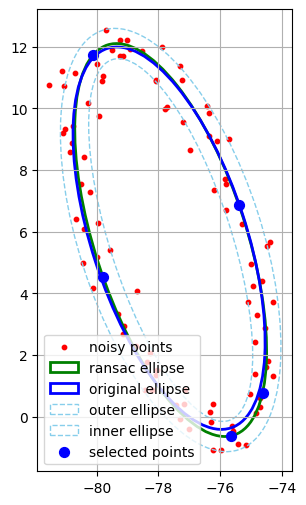

In [54]:
max_counter, ransac_ellipse_params, selected_points, ellipse_outer, ellipse_inner = ransac_ellipse(noisy_points, 0.5, 0.999, 0.3)

# Отрисовка
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(noisy_points[:, 0], noisy_points[:, 1], color='red', label='noisy points', s=10)

# Рисуем эллипс
ransac_ellipse_patch = Ellipse(
    xy=ransac_ellipse_params['center'],
    width=2 * ransac_ellipse_params['axis_a'],
    height=2 * ransac_ellipse_params['axis_b'],
    angle=ransac_ellipse_params['angle'],
    edgecolor='green',
    facecolor='none',
    linewidth=2,
    label='ransac ellipse'
)
ax.add_patch(ransac_ellipse_patch)

original_ellipse = Ellipse(
    xy          = ellipse_params['center'],
    width       = 2 * ellipse_params['axis_a'],
    height      = 2 * ellipse_params['axis_b'],
    angle       = ellipse_params['angle'],
    edgecolor   = 'blue',
    facecolor   = 'none',
    linewidth   = 2,
    label       = 'original ellipse'
)
ax.add_patch(original_ellipse)

outer_ellipse = Ellipse(
    xy          = ellipse_outer['center'],
    width       = 2 * ellipse_outer['axis_a'],
    height      = 2 * ellipse_outer['axis_b'],
    angle       = ellipse_outer['angle'],
    edgecolor   = 'skyblue',
    facecolor   = 'none',
    linewidth   = 1,
    linestyle='--',
    label       = 'outer ellipse'
)
ax.add_patch(outer_ellipse)

inner_ellipse = Ellipse(
    xy          = ellipse_inner['center'],
    width       = 2 * ellipse_inner['axis_a'],
    height      = 2 * ellipse_inner['axis_b'],
    angle       = ellipse_inner['angle'],
    edgecolor   = 'skyblue',
    facecolor   = 'none',
    linewidth   = 1,
    linestyle='--',
    label       = 'inner ellipse'
)
ax.add_patch(inner_ellipse)
 
# Выделяем 5 выбранных точек другим цветом
ax.scatter(selected_points[:, 0], selected_points[:, 1], color='blue', label='selected points', s=50)
print(f'max: {max_counter}')
print(f'accuracy: {max_counter/num_points}')
ax.set_aspect('equal')
ax.grid(True)
ax.legend()
plt.show()